#<b>8. Обучение сети Word2Vec на предобработанных текстах

1) Туториал RusVectores: https://github.com/akutuzov/webvectors/blob/master/preprocessing/rusvectores_tutorial.ipynb <br>
2) Туториал по обучению Word2vec: https://www.kaggle.com/pierremegret/gensim-word2vec-tutorial<br>
3) Немного теории: https://sysblok.ru/knowhow/word2vec-pokazhi-mne-svoj-kontekst-i-ja-skazhu-kto-ty/

## Подключение Google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

path_to_models = '/content/drive/MyDrive/SFU 4/ML/W2V_models/' #создадим папку, где будут храниться модели
os.makedirs(path_to_models, exist_ok=True)

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.4 MB/s eta 0:00:00


In [4]:
import gensim
import os
from gensim.test.utils import datapath
from gensim.models import  Word2Vec
#import logging  # Setting up the loggings to monitor gensim
#logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO) #настраиваем вывод справочной информации
from time import time

import warnings
warnings.filterwarnings("ignore") #убираем предупреждения

#для визуализации
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

import seaborn as sns
sns.set_style("darkgrid")

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from bokeh.models import ColumnDataSource, LabelSet
from bokeh.plotting import figure, show, output_file
from bokeh.io import output_notebook

from tqdm import tqdm
from nltk import FreqDist
import re

## Чтение текстов из нескольких файлов

### 1) Чтение документов из файла и первичная предобработка


In [5]:
#чтение одного файла с текстами
#def read_texts_one(file_name, path_to_file, delim='\n'):
  #f = open(path_to_file + file_name, 'r', encoding='utf8')
  #texts = f.read()
  #f.close()
  #return texts.split(delim)


#чтение нескольких файлов
def read_texts_several(folder):
  if folder[-1] != '/':
      folder += '/'

  texts = []
  files = os.listdir(folder)
  for file in files:
    f = open(folder + file, 'r', encoding='utf8')
    text = f.read()
    f.close()
    texts.append(text)
  return texts


#разбитие текстов на слова и представление в виде списка
def texts_to_list(texts):
  result_list = []
  for text in texts:
    words = text.split(' ')
    result_list.append(words)
  return result_list

In [6]:
texts = read_texts_several(
    folder = 'drive/MyDrive/SFU 3/Ex ml/2_морфологический_анализ_с_использованием_UDPipe/Lemma/Предобработанные'
)

### <b>Общая предобработка

In [7]:
result_texts = texts_to_list(texts) #result_texts готовы для загрузки в w2v
print('количество текстов', len(result_texts))

количество текстов 98


# <b> Обучение сети

###<b>Параметры сети:</b>
<li><i>sentences</i> - тексты</li>
<li><i>min_count</i> (=5 по ум-ю) - игнорирует все слова с общей абсолютной частотой ниже указанной</li>
<li><i>window</i> (=5) - максимальная длина учитываемого контекста.</li>
<li><i>size </i> (=100) - размерность вектора</li>
<li><i>sg </i> (=0) - если = 0, то CBOW; если = 1, то SkipGram</li>
<li><i>workers </i> (=3) - количество используемых потоков (для ускорения)</li>
---------------------------------------------------------------------------------<br>
<li><i>negative </i> (=5) - Если > 0, то будет использоваться негативное сэмплирование. Значение указывает, сколько слов используется в знаменателе софтмакса. Если установлено значение 0, то негативное сэмплирование не используется.</li>
---------------------------------------------------------------------------------
<li><i>total_examples</i> - общее количество текстов (model.corpus_count)</li>
<li><i>epochs</i> - количество эпох</li>

In [8]:
def build_train_W2V(texts, size, window, min_count, sg, epochs, print_info =False):
  t = time()
  model = Word2Vec(vector_size=size, #Размерность (длина) векторного представления каждого слова. Типичные значения: 50,100,300.
                  window=window, #Размер контекстного окна. Определяет максимальное расстояние между текущим словом и словом в его контексте, которое будет учитываться при обучении.
                  min_count=min_count, #Минимальная частота слова. Слова, встречающиеся в корпусе меньше этого числа раз, будут игнорированы и не попадут в словарь модели. Это помогает отфильтровать опечатки и очень редкие слова.
                  sg=sg, #Определяет алгоритм обучения: 0 для CBOW (Continuous Bag-of-Words) и 1 для Skip-Gram.
                  workers=1 #Количество потоков (ядер процессора), используемых для обучения. В Colab часто используется 1 для стабильности, но может быть увеличено для ускорения.
  )

  model.build_vocab(result_texts) #Построение словаря

  model.train(texts, #Корпус (предобработанные тексты), который будет использоваться для обучения.
              total_examples=model.corpus_count, #Общее количество предложений (или документов) в корпусе. Используется для корректного расчета прогресса обучения.
              epochs=epochs, #Количество эпох. Определяет, сколько раз модель пройдет по всему корпусу для обучения. Чем больше, тем дольше обучение, но лучше качество (до определенного момента).
              compute_loss=True #Установка в True позволяет модели рассчитывать и накапливать ошибку обучения (training loss) на каждой эпохе. Эта ошибка используется для оценки качества и выбора лучших параметров (estimate).
  )
  if(print_info):
    print('Time to train the model: {} mins'.format(round((time() - t) / 60, 2)))
    print('texts count:', model.corpus_count)
    print('vocab size:', model.corpus_total_words)

  return model

## <b> а) Самостоятельный подбор параметров

In [30]:
model = build_train_W2V(
          texts=result_texts,
          size=30,
          window=2,
          min_count=1,
          sg=0,
          epochs=100,
          print_info=True
)

Time to train the model: 0.29 mins
texts count: 98
vocab size: 59765


In [31]:
model.save(path_to_models+'newmodel') #сохраняем модель

In [32]:
model = Word2Vec.load(path_to_models+'newmodel') #загружаем модель

### <b>Оценка модели</b>
Чем МЕНЬШЕ, тем ЛУЧШЕ



In [35]:
model.get_latest_training_loss()

11233404.0

## <b>б) Автоматический подбор параметров

In [13]:
class Fine_tuning():
  def __init__(self, start, limit, step):
    self.start = start
    self.limit = limit
    self.step = step


class W2VParams():
  def __init__(self, size, window, min_count, sg, epochs):
    self.size=size,
    self.window=window,
    self.min_count=min_count,
    self.sg=sg,
    self.epochs=epochs

  def print(self):
    print('size:', self.size)
    print('window:', self.window)
    print('min_count:', self.min_count)
    print('sg:', self.sg)
    print('epochs:', self.epochs)


class Model_opt():
  def __init__(self):
    self.model = None
    self.params = None
    self.estimate = 1e100


def make_opt_model(texts,
                   fine_tuning_size,
                   fine_tuning_window,
                   fine_tuning_min_count,
                   fine_tuning_sg,
                   fine_tuning_epochs):
  models_opt = []
  model_type = ['CBOW', 'SkipGram']
  for sg in range(fine_tuning_sg.start, fine_tuning_sg.limit+1, fine_tuning_sg.step):
    best_model_opt = Model_opt()
    print('Training for model type', model_type[sg])
    for window in tqdm(range(fine_tuning_window.start, fine_tuning_window.limit+1, fine_tuning_window.step)):
      for size in range(fine_tuning_size.start, fine_tuning_size.limit+1, fine_tuning_size.step):
        for epochs in range(fine_tuning_epochs.start, fine_tuning_epochs.limit+1, fine_tuning_epochs.step):
          for min_count in range(fine_tuning_min_count.start, fine_tuning_min_count.limit+1, fine_tuning_min_count.step):
            model = build_train_W2V(
                          texts=texts,
                          size=size,
                          window=window,
                          min_count=min_count,
                          sg=sg,
                          epochs=epochs,
                          print_info=False
            )

            estimate = model.get_latest_training_loss()
            if estimate < best_model_opt.estimate:
              best_model_opt.model = model
              best_model_opt.params = W2VParams(size, window, min_count, sg, epochs)
              best_model_opt.estimate = estimate
    models_opt.append(best_model_opt)

  return models_opt

In [14]:
fine_tuning_size = Fine_tuning(
    start = 50,
    limit = 100,
    step = 50
)

fine_tuning_window = Fine_tuning(
    start = 3,
    limit = 5,
    step = 2
)

fine_tuning_min_count = Fine_tuning(
    start = 2,
    limit = 4,
    step = 1
)

fine_tuning_sg = Fine_tuning(
    start = 0,
    limit = 1,
    step = 1
)

fine_tuning_epochs = Fine_tuning(
    start = 10,
    limit = 20,
    step = 10
)

In [15]:
#займет некоторое время
models_opt = make_opt_model(
                  texts=result_texts,
                  fine_tuning_size=fine_tuning_size,
                  fine_tuning_window=fine_tuning_window,
                  fine_tuning_min_count=fine_tuning_min_count,
                  fine_tuning_sg=fine_tuning_sg,
                  fine_tuning_epochs=fine_tuning_epochs
)

Training for model type CBOW


100%|██████████| 2/2 [00:45<00:00, 22.80s/it]


Training for model type SkipGram


100%|██████████| 2/2 [01:54<00:00, 57.21s/it]


In [16]:
titles = ['CBOW', 'SkipGram']
for i in range(len(models_opt)):
  print(titles[i])
  print('model',i)
  print('estimate:', models_opt[i].estimate)
  models_opt[i].params.print()
  print('===================================')

CBOW
model 0
estimate: 1159815.75
size: (50,)
window: (5,)
min_count: (4,)
sg: (0,)
epochs: 10
SkipGram
model 1
estimate: 4248958.0
size: (50,)
window: (3,)
min_count: (4,)
sg: (1,)
epochs: 10


In [17]:
model_ind = 0
model = models_opt[model_ind].model

In [18]:
model.save(path_to_models+'opt_model0') #сохраняем модель

In [ ]:
model = Word2Vec.load(path_to_models+'opt_model0') #загружаем модел

## <b>Исследование текстов с помощью модели</b>

#### 0) Общая визуализация ключевых слов

In [19]:
def show_top_words(top_words, model):
    #Для визуализации всех ключевых слов
    top_words_vec = model.wv[top_words]
    tsne = TSNE(n_components=2, random_state=0)
    top_words_tsne = tsne.fit_transform(top_words_vec)

    output_notebook()
    p = figure(tools="pan,wheel_zoom,reset,save",
            toolbar_location="above",
            title="T-SNE visualization")

    source = ColumnDataSource(data=dict(x1=top_words_tsne[:,0],
                                        x2=top_words_tsne[:,1],
                                        names=top_words))

    p.scatter(x="x1", y="x2", size=8, source=source)

    labels = LabelSet(x="x1", y="x2", text="names", y_offset=6,
                    text_font_size="8pt", text_color="#555555",
                    source=source, text_align='center')
    p.add_layout(labels)

    show(p)


def build_freq_dict(texts):
    """Построение частотного словаря"""
    fd_res = FreqDist()
    for text in tqdm(texts):
        fd_res.update(re.split('\s+', text.strip()))
    return fd_res

def save_freq_dict(freq_dict, file_path):
    all_words_freqs = freq_dict.most_common(len(model.wv))
    with open(file_path, 'w', encoding='utf8') as file:
        file.write(f'word,frequency\n')
        for word, freq in all_words_freqs[:-1]:
            file.write(f'{word},{freq}\n')
        word_last, freq_last = all_words_freqs[-1]
        file.write(f'{word_last},{freq_last}\n')

In [20]:
freq_dict = build_freq_dict(texts)
save_freq_dict(freq_dict, 'freq_dict.csv') #закомментируйте, если не хотите сохранять

100%|██████████| 98/98 [00:00<00:00, 1605.06it/s]


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def show_top_words_by_pos_matplotlib(top_words, model, tag_sep='_'):
    # Получаем векторы слов
    top_words_vec = model.wv[top_words]

    # Применяем t-SNE для уменьшения размерности до 2D
    tsne = TSNE(n_components=2, random_state=0)
    top_words_tsne = tsne.fit_transform(top_words_vec)

    # Определяем части речи для каждого слова
    tags = [get_word_tag(word, tag_sep) for word in top_words]

    # Создаем DataFrame
    df = pd.DataFrame({
        'word': top_words,
        'x': top_words_tsne[:, 0],
        'y': top_words_tsne[:, 1],
        'tag': tags
    })

    # Создаем фигуру
    plt.figure(figsize=(12, 10))

    # Рисуем точки для каждой части речи
    for tag, color in tag_colors.items():
        if tag in df['tag'].values:
            tag_data = df[df['tag'] == tag]
            plt.scatter(tag_data['x'], tag_data['y'],
                       color=color, s=100, alpha=0.7, label=tag)

    # Добавляем подписи
    for i, row in df.iterrows():
        plt.annotate(row['word'], (row['x'], row['y']),
                    fontsize=9, alpha=0.8)

    plt.title('T-SNE visualization of top words colored by POS tags')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='Parts of Speech', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Статистика
    print("Распределение частей речи среди топ-слов:")
    tag_counts = df['tag'].value_counts()
    for tag, count in tag_counts.items():
        print(f"{tag}: {count} слов")

# Использование
top_words_freqs = freq_dict.most_common(50)
top_words = [word_freq[0] for word_freq in top_words_freqs]
show_top_words_by_pos_matplotlib(top_words, model)

NameError: name 'get_word_tag' is not defined

## Сделать возможность фильтровать близкие слова на основе частей речи

In [22]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 55.1 MB/s eta 0:00:00


In [23]:
import pymorphy3
pymorphy = pymorphy3.MorphAnalyzer()

In [24]:
dict_tags_Pymorphy = {
    'ADJF' : 'ADJ',
    'ADJS' : 'ADJ',
    'ADVB' : 'ADV',
    'COMP' : 'ADV',
    'GRND' : 'VERB',
    'INFN' : 'VERB',
    'NOUN' : 'NOUN',
    'PRED' : 'ADV',
    'PRTF' : 'ADJ',
    'PRTS' : 'VERB',
    'VERB' : 'VERB',
    'PREP' : 'PREP',
    'CONJ' : 'СONJ',
    'PRCL' : 'PRCL',
    'INTJ' : 'INTJ',
    'NUMR' : 'NUM',
    'NPRO' : 'PRON'
}

word_to_tag = None #словарь для случая, если слова без тегов

In [25]:
def build_tags_for_all_words():
    global word_to_tag
    word_to_tag = dict()
    for word in model.wv.key_to_index.keys():
        tag_pos = pymorphy.parse(word)[0].tag.POS
        if tag_pos is None:
            tag_pos = 'X'
        else:
            tag_pos = dict_tags_Pymorphy[tag_pos]
        word_to_tag[word] = tag_pos

def get_tag_from_dict(word):
    if word_to_tag is None:
        build_tags_for_all_words()
    return word_to_tag[word]


def get_word_tag(word, tag_sep):
    splitted_word = word.split(tag_sep)
    if len(splitted_word) == 1:
        return get_tag_from_dict(word)
    return splitted_word[-1]

In [26]:
def most_similar_by_tags(positive=None, negative=None, topn=10, desired_tags=None, tag_sep='_'):
    word_freq_lst = model.wv.most_similar(positive=positive, negative=negative, topn=len(model.wv))
    if desired_tags is None:
        if positive is None:
            positive = []
        if negative is None:
            negative = []
        tags_from_pos = [get_word_tag(word, tag_sep) for word in positive]
        tags_from_negs = [get_word_tag(word, tag_sep) for word in negative]
        desired_tags = set(tags_from_pos).union(tags_from_negs)
    res_lst = []
    for word, freq in word_freq_lst:
        if get_word_tag(word, tag_sep) in desired_tags:
            res_lst.append((word, freq))
        if len(res_lst) == topn:
            break
    return res_lst

In [36]:
# 1. Ассоциаты для ключевых слов
print("=== Ассоциаты для 'комик' ===")
print(model.wv.most_similar("комик", topn=10))
print("\n=== Ассоциаты для 'театр' ===")
print(model.wv.most_similar("театр", topn=10))
print("\n=== Ассоциаты для 'антрепренер' ===")
print(model.wv.most_similar("антрепренер", topn=10))

# 2. Косинусная близость между словами
print("\n=== Косинусная близость ===")
print("театр <-> антрепренер:", model.wv.similarity("театр", "антрепренер"))
print("театр <-> комик:", model.wv.similarity("театр", "комик"))
print("комик <-> антрепренер:", model.wv.similarity("комик", "антрепренер"))


=== Ассоциаты для 'комик' ===
[('приплюснутым', 0.7499369978904724), ('зайдя', 0.7415120601654053), ('растерявшийся', 0.7354180812835693), ('сигаев', 0.7317851781845093), ('дожидаясь', 0.7259266972541809), ('пересиливая', 0.7256824970245361), ('ферт', 0.6963975429534912), ('разом', 0.6954077482223511), ('вторникам', 0.6915786862373352), ('городу', 0.6803461909294128)]

=== Ассоциаты для 'театр' ===
[('писал', 0.7926272749900818), ('грабьте', 0.7631933689117432), ('служить', 0.7535282969474792), ('вовсе', 0.749173104763031), ('едем', 0.748542308807373), ('обязаны', 0.7365148663520813), ('устроить', 0.7358322739601135), ('берите', 0.7355378270149231), ('отпускать', 0.7320598363876343), ('читателя', 0.730850338935852)]

=== Ассоциаты для 'антрепренер' ===
[('жуков', 0.8452139496803284), ('сообщил', 0.8286131024360657), ('банка', 0.8163924813270569), ('подбежал', 0.8037986159324646), ('прибежал', 0.7996671795845032), ('взъерошенный', 0.7941322326660156), ('безбожников', 0.7908445000648499)

#### 1) 10 ассоциатов - model.wv.most_similar(positive=[слово])

In [37]:
model.wv.most_similar(positive=["комик"])

[('приплюснутым', 0.7499369978904724),
 ('зайдя', 0.7415120601654053),
 ('растерявшийся', 0.7354180812835693),
 ('сигаев', 0.7317851781845093),
 ('дожидаясь', 0.7259266972541809),
 ('пересиливая', 0.7256824970245361),
 ('ферт', 0.6963975429534912),
 ('разом', 0.6954077482223511),
 ('вторникам', 0.6915786862373352),
 ('городу', 0.6803461909294128)]

In [38]:
model.wv.most_similar(positive=["театр"])

[('писал', 0.7926272749900818),
 ('грабьте', 0.7631933689117432),
 ('служить', 0.7535282969474792),
 ('вовсе', 0.749173104763031),
 ('едем', 0.748542308807373),
 ('обязаны', 0.7365148663520813),
 ('устроить', 0.7358322739601135),
 ('берите', 0.7355378270149231),
 ('отпускать', 0.7320598363876343),
 ('читателя', 0.730850338935852)]

In [39]:
model.wv.most_similar(positive=["антрепренер"])

[('жуков', 0.8452139496803284),
 ('сообщил', 0.8286131024360657),
 ('банка', 0.8163924813270569),
 ('подбежал', 0.8037986159324646),
 ('прибежал', 0.7996671795845032),
 ('взъерошенный', 0.7941322326660156),
 ('безбожников', 0.7908445000648499),
 ('бледнеют', 0.788214921951294),
 ('оборвалось', 0.7868550419807434),
 ('фрак', 0.7846856713294983)]

### С фильтрацией по частям речи

In [ ]:
most_similar_by_tags(positive=["глаза"])

[('глазами', 0.9997707605361938),
 ('лицо', 0.9997475743293762),
 ('голове', 0.9997408390045166),
 ('человек', 0.9997142553329468),
 ('место', 0.9997134804725647),
 ('голову', 0.9996748566627502),
 ('время', 0.9996551871299744),
 ('слова', 0.9996502995491028),
 ('дело', 0.9996382594108582),
 ('дома', 0.9996345043182373)]

#### 2) 10 самых "неассоциатов" - model.wv.most_similar(negative=[слово])


In [ ]:
model.wv.most_similar(negative=["глаза"])  ## негативный - указывает на противоположность значения контекстов (в каком-то смысле)

[('хо', -0.6914198398590088),
 ('врет', -0.8738201856613159),
 ('молодость', -0.9027355909347534),
 ('балясы', -0.9208889603614807),
 ('ножки', -0.9528079628944397),
 ('теле', -0.9593474268913269),
 ('слезами', -0.9597123861312866),
 ('делаете', -0.9638351202011108),
 ('твоим', -0.9647077322006226),
 ('сильнее', -0.9654219746589661)]

In [ ]:
most_similar_by_tags(negative=["глаза"])

[('молодость', -0.9027355909347534),
 ('балясы', -0.9208889603614807),
 ('ножки', -0.9528079628944397),
 ('теле', -0.9593474268913269),
 ('слезами', -0.9597123861312866),
 ('матвея', -0.9687081575393677),
 ('чудеса', -0.969511091709137),
 ('жизнеописание', -0.9726672172546387),
 ('мастер', -0.9726744890213013),
 ('овес', -0.9737481474876404)]

In [ ]:
#С помощью параметра topn можно указать количество выводимых значений
model.wv.most_similar(negative=["глаза"], topn=20)

[('хо', -0.6914198398590088),
 ('врет', -0.8738201856613159),
 ('молодость', -0.9027355909347534),
 ('балясы', -0.9208889603614807),
 ('ножки', -0.9528079628944397),
 ('теле', -0.9593474268913269),
 ('слезами', -0.9597123861312866),
 ('делаете', -0.9638351202011108),
 ('твоим', -0.9647077322006226),
 ('сильнее', -0.9654219746589661),
 ('опустил', -0.9660021066665649),
 ('замигал', -0.9680516719818115),
 ('придавая', -0.968197762966156),
 ('матвея', -0.9687081575393677),
 ('наплевать', -0.9693744778633118),
 ('чудеса', -0.969511091709137),
 ('помирать', -0.9706171751022339),
 ('экий', -0.9714602828025818),
 ('останется', -0.971912145614624),
 ('жизнеописание', -0.9726672172546387)]

#### 3) Схожесть двух слов - model.wv.similarity(слово1, слово2)


In [ ]:
model.wv.similarity('театр','антрепренер')

np.float32(0.9983954)

In [ ]:
model.wv.similarity('театр','комик')

np.float32(0.9982925)

In [ ]:
model.wv.similarity('комик','антрепренер')

np.float32(0.9985121)

 #### 4) Лишнее слова из списка - model.wv.doesnt_match(список слов)

In [ ]:
model.wv.doesnt_match(['глаза','понимаю','слова', 'жизнь'])

'жизнь'

 #### 5) Вычитание ассоциатов: глаза - слова + место

In [ ]:
model.wv.most_similar(positive=['глаза','слова'], negative=['место'])

[('нужно', 0.999386191368103),
 ('всё', 0.9993489384651184),
 ('говорит', 0.9993115663528442),
 ('голове', 0.9992967247962952),
 ('могу', 0.9992965459823608),
 ('своих', 0.9992718696594238),
 ('богу', 0.9992604851722717),
 ('знаете', 0.9992539286613464),
 ('голову', 0.9992471933364868),
 ('почему', 0.99924236536026)]

### 6) Визуализация

In [40]:
#визуализация
def tsnescatterplot(model, word, list_names, cnt, pca_emb_size):
    """ Plot in seaborn the results from the t-SNE dimensionality reduction algorithm of the vectors of a query word,
    its list of most similar words, and a list of words.
    """
    size = model.vector_size
    arrays = np.empty((0, size), dtype='f')
    word_labels = [word]
    color_list  = ['red']

    # adds the vector of the query word
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)

    # gets list of most similar words
    close_words = model.wv.most_similar([word], topn=cnt)

    # adds the vector for each of the closest words to the array
    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    # adds the vector for each of the words from list_names to the array
    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('blue')
        arrays = np.append(arrays, wrd_vector, axis=0)

    # Reduces the dimensionality from size to 50 dimensions with PCA
    reduc = PCA(n_components=pca_emb_size).fit_transform(arrays)

    # Finds t-SNE coordinates for 2 dimensions
    np.set_printoptions(suppress=True)

    Y = TSNE(n_components=2, random_state=0, perplexity=15).fit_transform(reduc)

    # Sets everything up to plot
    df = pd.DataFrame({'x': [x for x in Y[:, 0]],
                       'y': [y for y in Y[:, 1]],
                       'words': word_labels,
                       'color': color_list})

    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)

    # Basic plot
    p1 = sns.regplot(data=df,
                     x="x",
                     y="y",
                     fit_reg=False,
                     marker="o",
                     scatter_kws={'s': 40,
                                  'facecolors': df['color']
                                 }
                    )

    # Adds annotations one by one with a loop
    for line in range(0, df.shape[0]):
         p1.text(df["x"][line],
                 df['y'][line],
                 '  ' + df["words"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 color=df['color'][line],
                 weight='normal'
                ).set_size(15)


    plt.xlim(Y[:, 0].min()-50, Y[:, 0].max()+50)
    plt.ylim(Y[:, 1].min()-50, Y[:, 1].max()+50)

    plt.title('t-SNE visualization for {}'.format(word.title()))

def print_most_least_similar(model, word, cnt, pca_emb_size):
    list_less = [i[0] for i in model.wv.most_similar(negative=[word], topn=cnt)]
    tsnescatterplot(model, word, list_less, cnt, pca_emb_size)

Визуализации наиболее и наименее близких слов к заданному:

<li>model - модель word2vec</li>
<li>word - задаваемое слово</li>
<li>cnt - число выводимых ассоциатов</li>

Зеленый цвет - наиболее близкие<br>
Синий цвет - наименее близкие

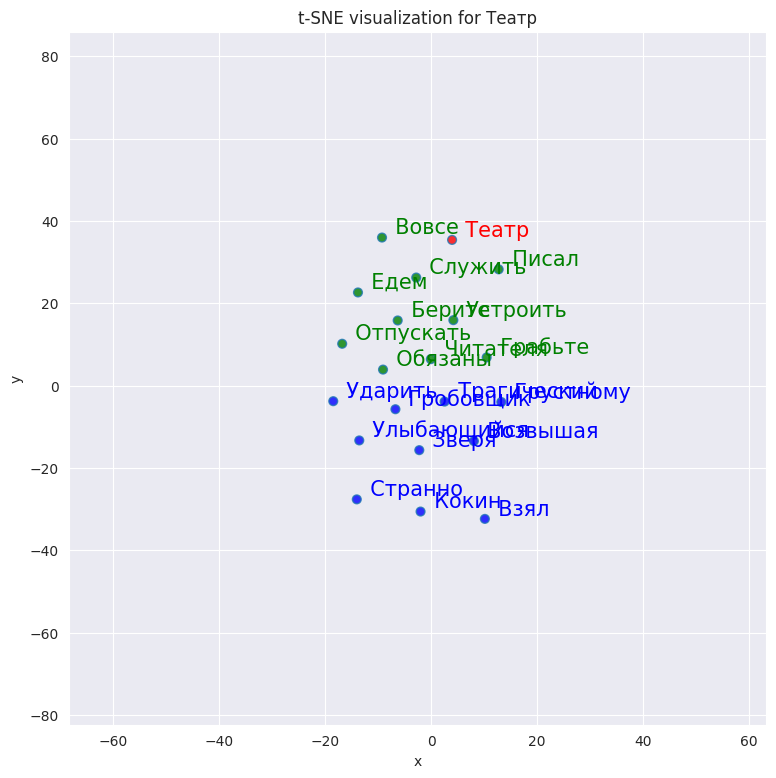

In [41]:
print_most_least_similar(model = model,
                         word = 'театр',
                         cnt = 10,
                         pca_emb_size = 5,  # попробуйте между 10 и model.vector_size (лучше в диапазоне 10-20)
)

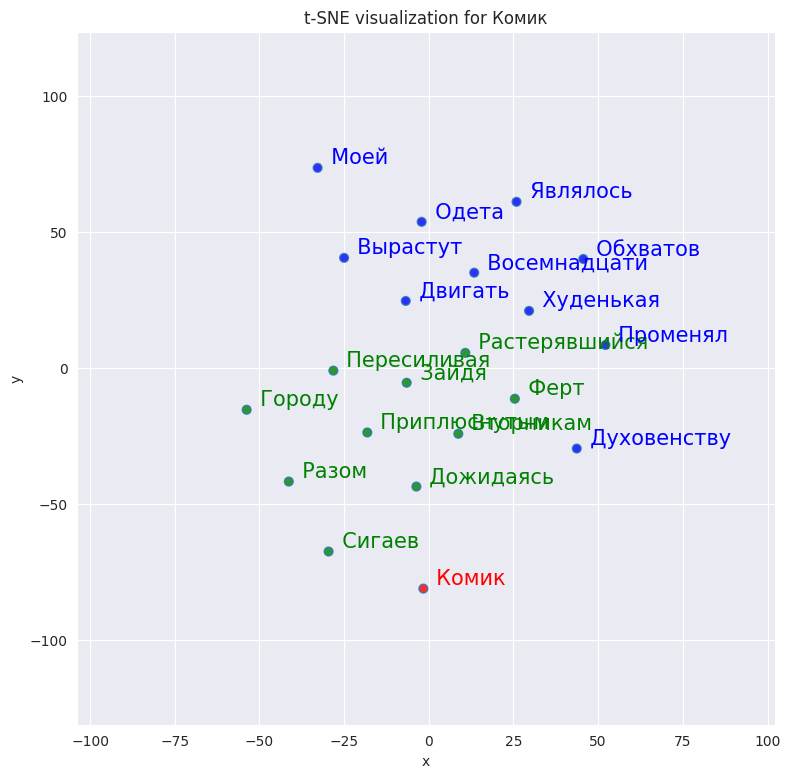

In [42]:
print_most_least_similar(model = model,
                         word = 'комик',
                         cnt = 10,
                         pca_emb_size = 20,  # попробуйте между 10 и model.vector_size (лучше в диапазоне 10-20)
)

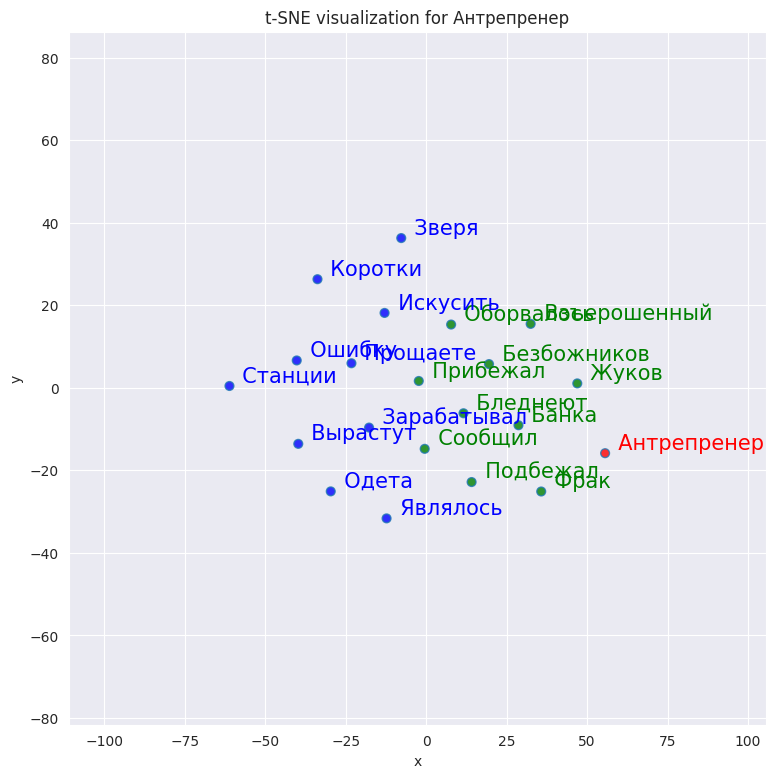

In [44]:
print_most_least_similar(model = model,
                         word = 'антрепренер',
                         cnt = 10,
                         pca_emb_size = 10,  # попробуйте между 10 и model.vector_size (лучше в диапазоне 10-20)
)